In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import RYGate
from qiskit.quantum_info import Statevector

from lib.gates import TranspositionGate, delay_gate, apply_on_buffer, process_sample
from lib.fir_util import power_complementary_fir, direct_pair_to_lattice_real, lattice_freq_response

plt.style.use("plots.mplstyle")

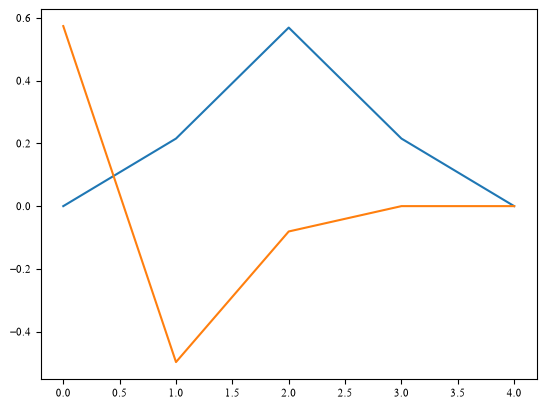

In [2]:
# Design a filter H0 and its power complement H1

H0 = scipy.signal.firwin(5, 0.4, window="hann")
# Try to ensure filter is bounded <= 1
H0 /= np.max(np.abs(scipy.signal.freqz(H0)[1]))
H1 = power_complementary_fir(H0)

plt.plot(H0)
plt.plot(H1)
plt.show()

[ 5.52863852e-05 -7.17919871e-01 -1.71362616e+00 -7.17957505e-01
  3.14159265e+00]


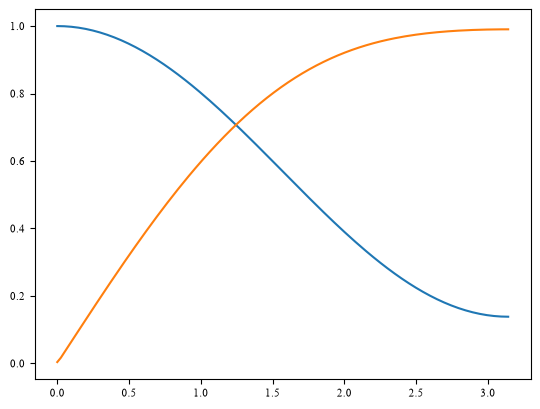

In [3]:
# Convert direct form to lattice coefficients

theta = direct_pair_to_lattice_real(H0, H1)
print(theta)

# Check frequency response
freq = np.linspace(0, np.pi, 128)
H0f, H1f = lattice_freq_response(theta, freq)

plt.plot(freq, np.abs(H0f))
plt.plot(freq, np.abs(H1f))
plt.show()

In [4]:
def fir_circ_real(circ: QuantumCircuit, b_reg, q_reg, theta, proj_delay: int):
    """
    Construct FIR circuit.

    Buffer k=0 used as work buffer. k=1,...,order used for unit delays,
    and k=order+1 used for projection.
    """

    order = len(theta) - 1

    for i in range(order+1):
        if i > 0:
            delay_gate(circ, b_reg, q_reg, 0, '1', delay=1, buffer=i)
        apply_on_buffer(circ, b_reg, q_reg, RYGate(theta[i]), 0)
    
    delay_gate(circ, b_reg, q_reg, 0, '1', delay=proj_delay, buffer=order+1)



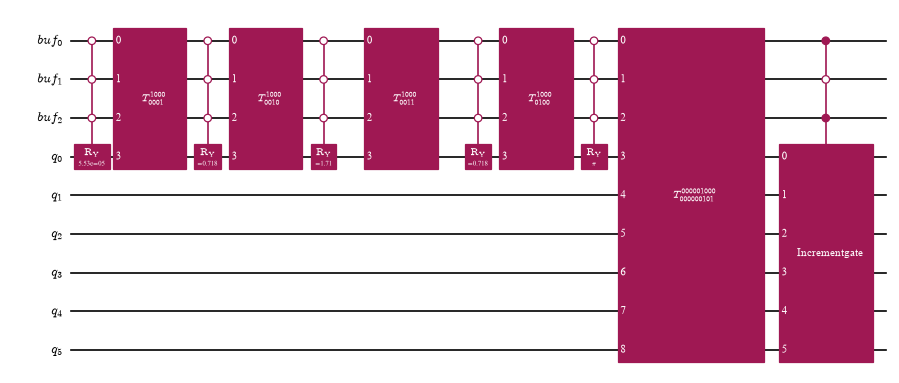

In [5]:
# Buffer register (add more qubits to support higher-order filter)
b_reg = QuantumRegister(3, "buf")
# Data register (more qubits for longer signal)
q_reg = QuantumRegister(6, "q")

fir_circ = QuantumCircuit(b_reg, q_reg)

fir_circ_real(fir_circ, b_reg, q_reg, theta, 2**len(q_reg))

fir_circ.draw("mpl", scale=0.6)

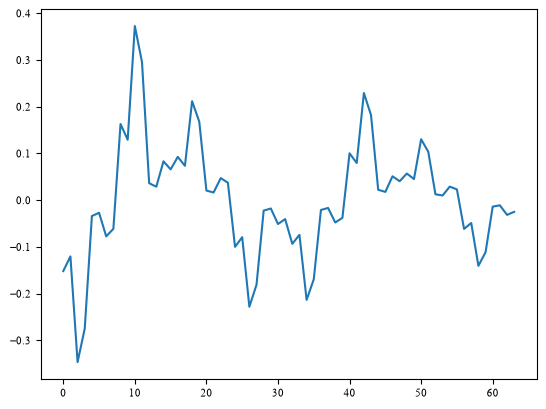

In [6]:
# Prepare a signal in buffer -1

prepare = QuantumCircuit(b_reg, q_reg)

# Select buffer 0b111..
prepare.x(b_reg)

np.random.seed(72)
for q in q_reg:
    prepare.ry(np.random.uniform(-2*np.pi, 2*np.pi), q)

# Uniform superposition
# prepare.h(q_reg)
# Make a square wave
# prepare.z(q_reg[0])

prepare.draw("mpl", scale=0.6)

st = Statevector.from_circuit(prepare)

stride = 2**len(b_reg)
signal_x = st.data[stride-1::stride]

plt.plot(np.real(signal_x))
plt.show()


In [7]:
# Filter the signal

full_circ = QuantumCircuit(b_reg, q_reg)

full_circ.compose(prepare, inplace=True)

for i in range(2**len(q_reg)):
    process_sample(
        full_circ, b_reg, q_reg,
        fir_circ,
        sample_buffer=2**len(b_reg)-1, sample_pos=i,
        proc_buffer=0
    )

# Too large to draw
# full_circ.draw("mpl", scale=0.6)

In [8]:

# TODO: Use Aer simulator which should be more efficient
st = Statevector.from_circuit(full_circ)

stride = 2**len(b_reg)
signal_y = st.data[stride-1::stride]

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


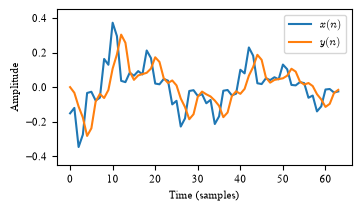

In [9]:
plt.figure(figsize=(3.5, 2), layout="constrained")

plt.plot(np.real(signal_x), label="$x(n)$")
plt.plot(np.real(signal_y), label="$y(n)$")

plt.ylim(-0.45, 0.45)
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.legend()
plt.savefig("figures/fig3.pdf")
plt.show()